# Primary dataset feature engineering & normalisation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

In [2]:
# load df_clean from csv
df_clean = pd.read_csv('data/IEEE-CIS/df_clean.csv')
df_clean = df_clean.copy()

## 1. Pre-split feature engineering

In [3]:
# extract time features, like day of week, hour, etc. from TransactionDT
df_clean['TransactionDT'] = pd.to_datetime(df_clean['TransactionDT'], unit='s')
df_clean['DayOfWeek'] = df_clean['TransactionDT'].dt.dayofweek
df_clean['Hour'] = df_clean['TransactionDT'].dt.hour

In [4]:
# normalise D columns against TransactionDT, check range of values before and after normalisation
d_cols = [f'D{i}' for i in range(1, 16)]
transactionDT_seconds = df_clean['TransactionDT'].astype('int64') // 10**9  # convert datetime to seconds
for col in d_cols:
    df_clean[col] = df_clean[col] / (transactionDT_seconds + 1)  # add 1 to avoid division by zero
    print(f"Range of {col}: {df_clean[col].min()} to {df_clean[col].max()}")

Range of D1: 0.0 to 640.0
Range of D2: 0.0 to 640.0
Range of D3: 0.0 to 819.0
Range of D4: -122.0 to 869.0
Range of D5: 0.0 to 819.0
Range of D6: -83.0 to 873.0
Range of D7: 0.0 to 843.0
Range of D8: 0.0 to 1707.7916259765625
Range of D9: 0.0 to 0.9583330154418944
Range of D10: 0.0 to 876.0
Range of D11: -53.0 to 670.0
Range of D12: -83.0 to 648.0
Range of D13: 0.0 to 847.0
Range of D14: -193.0 to 878.0
Range of D15: -83.0 to 879.0


In [5]:
# map email domains to categories like 'gmail', 'yahoo', 'hotmail', etc.
def map_email_domain(domain):
    if pd.isnull(domain):
        return 'unknown'
    domain = domain.lower()
    if 'gmail' in domain:
        return 'gmail'
    elif 'yahoo' in domain:
        return 'yahoo'
    elif 'hotmail' in domain or 'outlook' in domain:
        return 'hotmail'
    else:
        return 'other'
df_clean['EmailDomain'] = df_clean['P_emaildomain'].apply(map_email_domain)

In [6]:
# for the other email domains, what are the unique values and their counts
other_domains = df_clean[df_clean['EmailDomain'] == 'other']['P_emaildomain'].value_counts()
print(other_domains)

P_emaildomain
anonymous.com       36998
aol.com             28289
comcast.net          7888
icloud.com           6267
msn.com              4092
att.net              4033
live.com             3041
sbcglobal.net        2970
verizon.net          2705
ymail.com            2396
bellsouth.net        1909
me.com               1522
cox.net              1393
optonline.net        1011
charter.net           816
live.com.mx           749
rocketmail.com        664
mail.com              559
earthlink.net         514
mac.com               436
juno.com              322
aim.com               315
roadrunner.com        305
windstream.net        305
frontier.com          280
embarqmail.com        260
web.de                240
netzero.com           230
twc.com               230
prodigy.net.mx        207
centurylink.net       205
netzero.net           196
frontiernet.net       195
q.com                 189
suddenlink.net        175
cfl.rr.com            172
sc.rr.com             164
cableone.net          15

In [7]:
# map live & msn to hotmail, anonymous to anonymous, aol to aol, and the rest to other
def map_email_domain_v2(domain):
    if pd.isnull(domain):
        return 'unknown'
    domain = domain.lower()
    if 'gmail' in domain:
        return 'gmail'
    elif 'yahoo' in domain:
        return 'yahoo'
    elif 'hotmail' in domain or 'outlook' in domain or 'live' in domain or 'msn' in domain:
        return 'hotmail'
    elif 'anonymous' in domain:
        return 'anonymous'
    elif 'aol' in domain:
        return 'aol'
    else:
        return 'other'
df_clean['EmailDomain'] = df_clean['P_emaildomain'].apply(map_email_domain_v2)

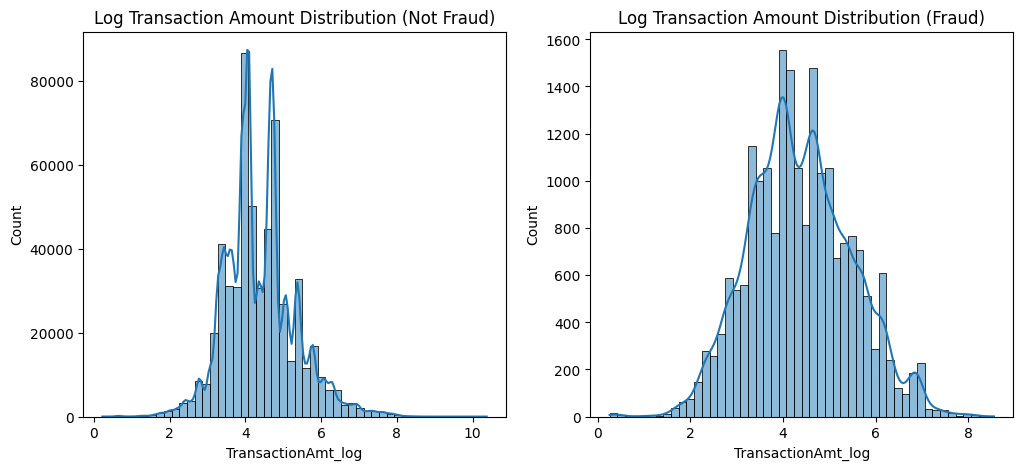

In [8]:
# log transform TransactionAmt to reduce skewness, plot histogram after, split by fraud status
df_clean['TransactionAmt_log'] = np.log1p(df_clean['TransactionAmt'])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean[df_clean['isFraud'] == 0]['TransactionAmt_log'], bins=50, kde=True)
plt.title('Log Transaction Amount Distribution (Not Fraud)')
plt.subplot(1, 2, 2)
sns.histplot(df_clean[df_clean['isFraud'] == 1]['TransactionAmt_log'], bins=50, kde=True)
plt.title('Log Transaction Amount Distribution (Fraud)')
plt.show()

In [9]:
# combinations of card1, card2, etc. to capture user behaviour patterns
df_clean['CardCombination'] = df_clean['card1'].astype(str) + '_' + df_clean['card2'].astype(str) + '_' + df_clean['card3'].astype(str) + '_' + df_clean['card4'].astype(str) + '_' + df_clean['card5'].astype(str) + '_' + df_clean['card6'].astype(str)

In [10]:
# binarising missingness of D and M columns to capture potential patterns in missing data
for col in d_cols + [f'M{i}' for i in range(1, 10)]:
    df_clean[col + '_missing'] = df_clean[col].isnull().astype(int)

In [11]:
# binarising missingness of id columns to capture potential patterns in missing data, taking note there are some id columnds removeed in the cleaning process, so only apply to the remaining ones
id_cols = [col for col in df_clean.columns if col.startswith('id')]
for col in id_cols:
    df_clean[col + '_missing'] = df_clean[col].isnull().astype(int)

## 2. Split train/test chronologically & fill NaN

In [12]:
# split train/test chronologically based on TransactionDT, using the last 20% of transactions as test set
df_clean = df_clean.sort_values('TransactionDT')
split_index = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:split_index]
test_df = df_clean.iloc[split_index:]

In [13]:
# replace NaN values with minimum value for each column to avoid issues with log transformation and model training in both train and test sets
for col in train_df.columns:
    if train_df[col].dtype in [np.float64, np.int64]:
        min_value = train_df[col].min()
        train_df[col] = train_df[col].fillna(min_value)
        test_df[col] = test_df[col].fillna(min_value)


In [14]:
train_df = train_df.copy()
test_df = test_df.copy()

## 3. Post-split feature engineering

In [15]:
# frequency encoding of high cardinality features like card combinations, email domains, etc. to capture potential patterns while avoiding overfitting
for col in ['CardCombination', 'EmailDomain']:
    freq_encoding = train_df[col].value_counts() / len(train_df)
    train_df[col + '_freq'] = train_df[col].map(freq_encoding)
    test_df[col + '_freq'] = test_df[col].map(freq_encoding).fillna(0)  # fill NaN with 0 for unseen categories in test set

In [16]:
# transaction velocity features: number of transactions, average transaction amount, etc. for each card combination in the past 24 hours, 7 days, etc.
def velocity_features_fast(df, time_windows=[24, 168]):
    df = df.sort_values('TransactionDT').reset_index(drop=True)
    
    for window in time_windows:
        window_sec = window * 3600
        counts = []
        avg_amounts = []
        
        for card, group in df.groupby('CardCombination'):
            times = group['TransactionDT'].values
            amounts = group['TransactionAmt'].values
            n = len(times)
            
            cnt = np.zeros(n)
            avg = np.zeros(n)
            
            left = 0
            for right in range(n):
                # slide left pointer forward
                while times[right] - times[left] > window_sec:
                    left += 1
                # window is [left, right), excludes current transaction
                cnt[right] = right - left
                if right > left:
                    avg[right] = amounts[left:right].mean()
            
            counts.append(pd.Series(cnt, index=group.index))
            avg_amounts.append(pd.Series(avg, index=group.index))
        
        df[f'transactions_last_{window}h'] = pd.concat(counts).sort_index()
        df[f'avg_amount_last_{window}h'] = pd.concat(avg_amounts).sort_index()
    
    return train_df, test_df

# call velocity features function
train_df, test_df = velocity_features_fast(train_df, time_windows=[24, 168])

In [19]:
# spending pattern deviation features: deviation of current transaction amount from average amount for that card combination, email domain, etc. to capture unusual spending behaviour
def spending_deviation_features(train_df, test_df):
    card_avg  = train_df.groupby('CardCombination')['TransactionAmt'].mean()
    email_avg = train_df.groupby('EmailDomain')['TransactionAmt'].mean()

    for df in [train_df, test_df]:
        df['CardCombination_avg'] = df['CardCombination'].map(card_avg)
        df['EmailDomain_avg']     = df['EmailDomain'].map(email_avg)
        df['Amount_CardCombination_deviation'] = df['TransactionAmt'] - df['CardCombination_avg']
        df['Amount_EmailDomain_deviation']     = df['TransactionAmt'] - df['EmailDomain_avg']

    return train_df, test_df

# call spending deviation features function
train_df, test_df = spending_deviation_features(train_df, test_df)

In [22]:
# rolling fraud rate by category like email domain, card combination, etc. to capture recent fraud trends for those categories
def rolling_fraud_rate(train_df, test_df):
    for col in ['CardCombination', 'EmailDomain']:
        # compute mean fraud rate per category from train only
        fraud_rate_map = train_df.groupby(col)['isFraud'].mean()
        global_mean = train_df['isFraud'].mean()
        
        # map to all splits, unknown categories get global mean
        train_df[f'{col}_rolling_fraud_rate'] = train_df[col].map(fraud_rate_map).fillna(global_mean)
        test_df[f'{col}_rolling_fraud_rate']  = test_df[col].map(fraud_rate_map).fillna(global_mean)
    
    return train_df, test_df

train_df, test_df = rolling_fraud_rate(train_df, test_df)

In [23]:
# User-level aggregates based on card combination - mean, max, std
def user_level_aggregates(train_df, test_df):
    for col in ['CardCombination']:
        agg = train_df.groupby(col)['TransactionAmt'].agg(['mean', 'max', 'std']).reset_index()
        agg.columns = [col, f'{col}_TransactionAmt_mean', f'{col}_TransactionAmt_max', f'{col}_TransactionAmt_std']
        train_df = train_df.merge(agg, on=col, how='left')
        test_df = test_df.merge(agg, on=col, how='left')
    return train_df, test_df

# call user-level aggregates function
train_df, test_df = user_level_aggregates(train_df, test_df)

## 4. Target encoding

In [26]:
# k-fold target encoding of categorical features like email domain, card combination, etc. to capture relationship with target while avoiding overfitting
def target_encode(train_df, test_df, col, target='isFraud', n_s =5):
    kf = KFold(n_splits=n_s, shuffle=True, random_state=42)
    train_encoded = pd.Series(index=train_df.index, dtype=float)
    
    for train_index, val_index in kf.split(train_df):
        X_train, X_val = train_df.iloc[train_index], train_df.iloc[val_index]
        mean_target = X_train.groupby(col)[target].mean()
        train_encoded.iloc[val_index] = X_val[col].map(mean_target)
    
    # For test set, use the mean target from the entire training set
    overall_mean_target = train_df.groupby(col)[target].mean()
    test_encoded = test_df[col].map(overall_mean_target).fillna(overall_mean_target.mean())
    
    return train_encoded, test_encoded

cols_to_encode = ['P_emaildomain', 'R_emaildomain', 'CardCombination']

for col in cols_to_encode:
    train_df[f'{col}_target_enc'], test_df[f'{col}_target_enc'] = target_encode(
        train_df, test_df, col=col
    )

In [28]:
# list all columns in train_df, shape to check the new features
print(train_df.columns)
print(train_df.shape)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'Amount_CardCombination_deviation', 'Amount_EmailDomain_deviation',
       'CardCombination_rolling_fraud_rate', 'EmailDomain_rolling_fraud_rate',
       'CardCombination_TransactionAmt_mean',
       'CardCombination_TransactionAmt_max',
       'CardCombination_TransactionAmt_std', 'P_emaildomain_target_enc',
       'R_emaildomain_target_enc', 'CardCombination_target_enc'],
      dtype='str', length=462)
(472432, 462)


In [29]:
# save train_df and test_df to csv
train_df.to_csv('data/IEEE-CIS/train_encoded.csv', index=False)
test_df.to_csv('data/IEEE-CIS/test_encoded.csv', index=False)